# RQ5: Model Ranking

**Research Question:** Which model ranks best overall across multiple evaluation metrics?

- Fresh preprocessor per model (no shared state)
- XGBoost uses `scale_pos_weight` (consistent imbalance handling)
- Composite Borda score added: ranks are summed and re-ranked, giving a single overall winner
- F1 and AUC used as primary ranking metrics (accuracy alone is insufficient for imbalanced data)


Raw scores:

              Model  Accuracy  Precision  Recall    F1   AUC
Logistic Regression     0.658      0.036   0.436 0.066 0.567
      Random Forest     0.973      0.000   0.000 0.000 0.552
                SVM     0.781      0.027   0.200 0.048 0.523
            XGBoost     0.964      0.050   0.018 0.027 0.576

RQ5 Model Rankings (lower rank = better):

              Model  Rank_Accuracy  Rank_Precision  Rank_Recall  Rank_F1  Rank_AUC  Borda_Sum  Overall_Rank
Logistic Regression              4               2            1        1         2         10             1
      Random Forest              1               4            4        4         3         16             4
                SVM              3               3            2        2         4         14             3
            XGBoost              2               1            3        3         1         10             1


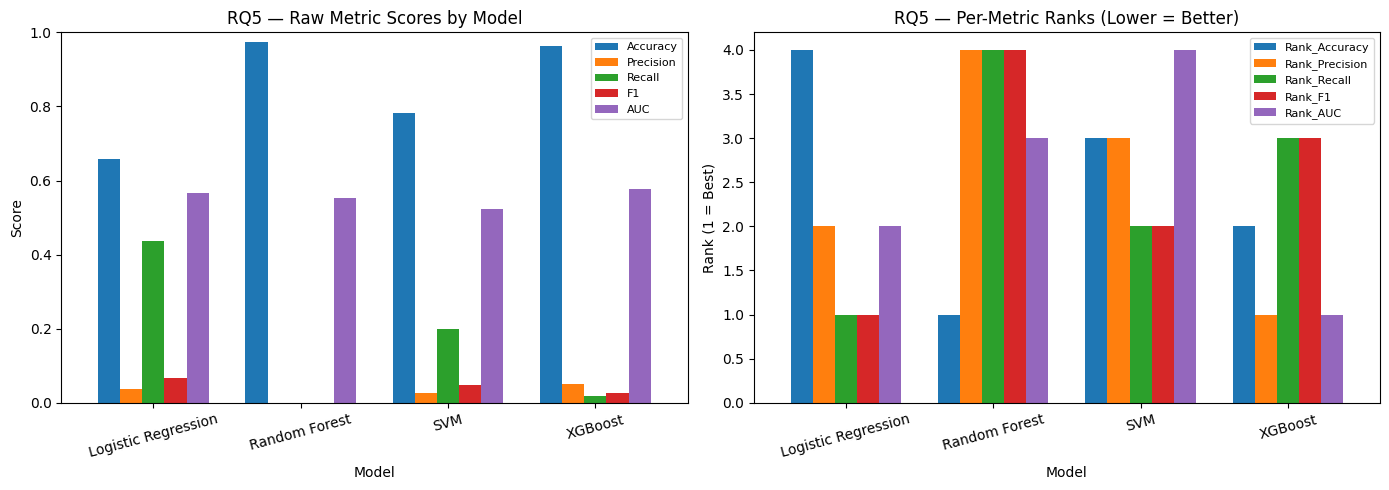


Overall considering by Borda count: Logistic Regression


In [4]:
#IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#LOAD
df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')
if 'patient_id' in df.columns:
    df = df.drop(columns=['patient_id'])

y = df['mortality']
X = df.drop(columns=['mortality'])

numeric_cols     = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def make_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler',  StandardScaler())
        ]), numeric_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])
#MODELS
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', RandomForestClassifier(
            class_weight='balanced', random_state=42, n_estimators=100
        ))
    ]),
    'SVM': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', SVC(probability=True, class_weight='balanced'))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', make_preprocessor()),
        ('model', XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,
            random_state=42
        ))
    ])
}

#EVALUATE
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    results.append([
        name,
        round(accuracy_score(y_test, y_pred), 3),
        round(precision_score(y_test, y_pred, zero_division=0), 3),
        round(recall_score(y_test, y_pred, zero_division=0), 3),
        round(f1_score(y_test, y_pred, zero_division=0), 3),
        round(roc_auc_score(y_test, y_prob), 3)
    ])

results_df = pd.DataFrame(results,
    columns=['Model','Accuracy','Precision','Recall','F1','AUC'])
print("\nRaw scores:\n")
print(results_df.to_string(index=False))
#RANKING (Borda method)
rank_df = results_df.copy()

for metric in ['Accuracy','Precision','Recall','F1','AUC']:
    rank_df[f'Rank_{metric}'] = rank_df[metric].rank(
        ascending=False, method='min').astype(int)

rank_cols = ['Rank_Accuracy','Rank_Precision','Rank_Recall','Rank_F1','Rank_AUC']
rank_df['Borda_Sum']   = rank_df[rank_cols].sum(axis=1)
rank_df['Overall_Rank'] = rank_df['Borda_Sum'].rank(ascending=True, method='min').astype(int)

print("\nRQ5 Model Rankings (lower rank = better):\n")
display_cols = ['Model'] + rank_cols + ['Borda_Sum','Overall_Rank']
print(rank_df[display_cols].to_string(index=False))

rank_df.to_csv('rq5_ranking.csv', index=False)
#VISUALISATION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw scores
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1','AUC']].plot(
    kind='bar', ax=axes[0], width=0.75
)
axes[0].set_title('RQ5 — Raw Metric Scores by Model')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='upper right', fontsize=8)

# Right: Borda rankings (lower = better)
rank_df.set_index('Model')[rank_cols].plot(
    kind='bar', ax=axes[1], width=0.75
)
axes[1].set_title('RQ5 — Per-Metric Ranks (Lower = Better)')
axes[1].set_ylabel('Rank (1 = Best)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('rq5_ranking_plot.pdf')
plt.show()

winner = rank_df.loc[rank_df['Overall_Rank']==1,'Model'].values[0]
print(f"\nOverall considering by Borda count: {winner}")
